In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

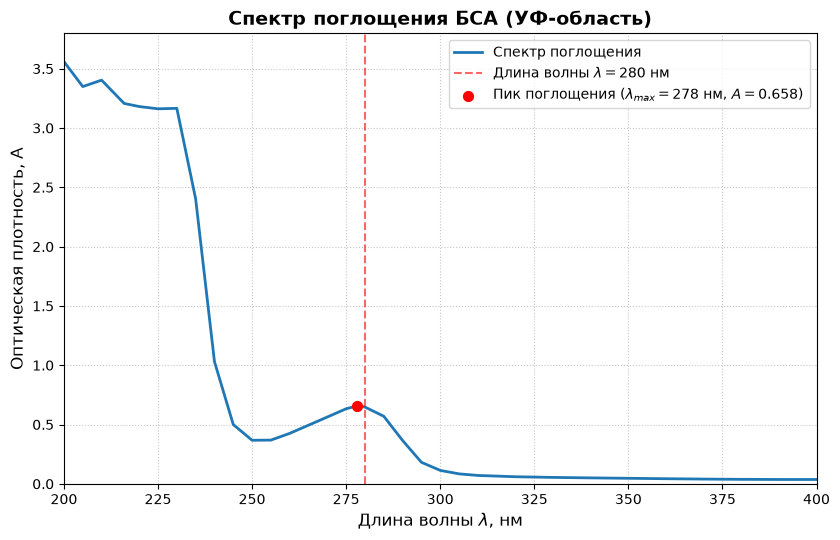

In [6]:
import matplotlib.pyplot as plt

data = [
    (400, 0.0365), (390, 0.0366), (380, 0.0379), (370, 0.0400),
    (360, 0.0431), (350, 0.0467), (340, 0.0501), (330, 0.0541),
    (320, 0.0598), (310, 0.0707), (305, 0.0840), (300, 0.1133),
    (295, 0.1816), (290, 0.3657), (285, 0.5697), (280, 0.6473),
    (278, 0.6578), (275, 0.6329), (270, 0.5635), (265, 0.4945),
    (260, 0.4254), (255, 0.3687), (250, 0.3672), (245, 0.4999),
    (240, 1.0306), (235, 2.4030), (230, 3.1657), (225, 3.1618),
    (220, 3.1809), (216, 3.2070), (210, 3.4034), (205, 3.3492),
    (200, 3.5599)
]

wavelengths, absorbance = zip(*sorted(data))

plt.figure(figsize=(8.5, 5.5))
plt.plot(wavelengths, absorbance, color='#1f77b4', linewidth=2, label='Спектр поглощения')

# Пунктирная линия для стандартной длины волны 280 нм
plt.axvline(x=280, color='r', linestyle='--', alpha=0.6, label=r'Длина волны $\lambda = 280$ нм')

# Отдельная подпись для красной точки (максимум при 278 нм)
plt.scatter([278], [0.6578], color='red', s=50, zorder=5, 
            label=r'Пик поглощения ($\lambda_{max} = 278$ нм, $A = 0.658$)')

plt.title('Спектр поглощения БСА (УФ-область)', fontsize=14, fontweight='bold')
plt.xlabel(r'Длина волны $\lambda$, нм', fontsize=12)
plt.ylabel('Оптическая плотность, A', fontsize=12)
plt.xlim(200, 400)
plt.ylim(0, 3.8)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()

plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\c'
<>:17: SyntaxWarning: invalid escape sequence '\c'
/var/folders/3v/phzdpch17dxg8rxj7bhjfmw40000gn/T/ipykernel_63823/2827295264.py:17: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(x_fit, y_fit, color='red', linestyle='--', label=f'Аппроксимация: $A = {slope:.4f} \cdot C - {-intercept:.4f}$ ($R^2 = {r2:.3f}$)')


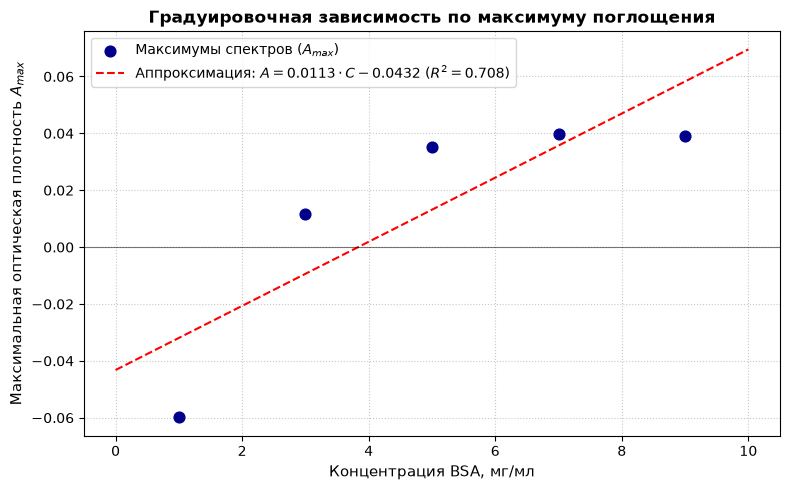

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Данные максимумов
concentrations = np.array([1, 3, 5, 7, 9])
abs_max = np.array([-0.0598, 0.0117, 0.0352, 0.0398, 0.0389])

# Линейная регрессия методом наименьших квадратов
slope, intercept = np.polyfit(concentrations, abs_max, 1)
r2 = np.corrcoef(concentrations, abs_max)[0, 1]**2

x_fit = np.linspace(0, 10, 100)
y_fit = slope * x_fit + intercept

plt.figure(figsize=(8, 5))
plt.scatter(concentrations, abs_max, color='darkblue', s=60, zorder=5, label='Максимумы спектров ($A_{max}$)')
plt.plot(x_fit, y_fit, color='red', linestyle='--', label=f'Аппроксимация: $A = {slope:.4f} \cdot C - {-intercept:.4f}$ ($R^2 = {r2:.3f}$)')

plt.title('Градуировочная зависимость по максимуму поглощения', fontsize=12, fontweight='bold')
plt.xlabel('Концентрация BSA, мг/мл', fontsize=11)
plt.ylabel('Максимальная оптическая плотность $A_{max}$', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()

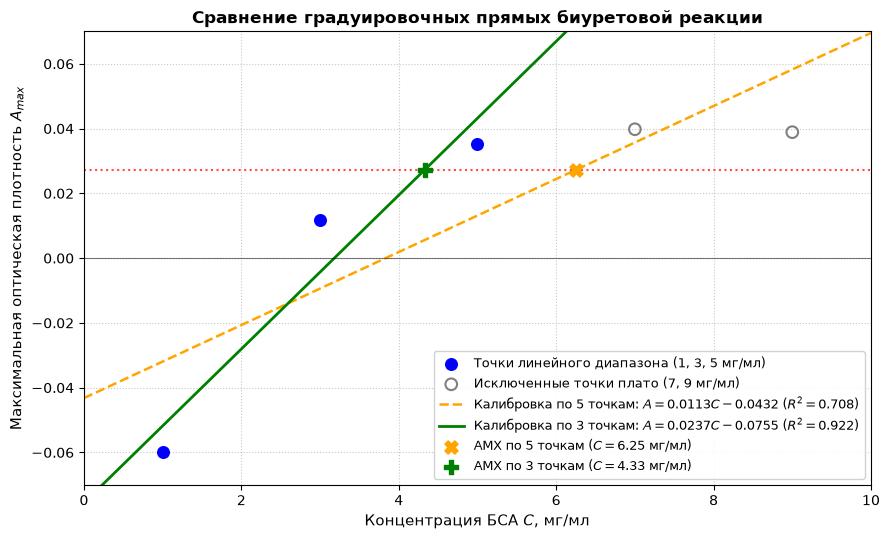

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Экспериментальные данные
C_all = np.array([1, 3, 5, 7, 9])
A_all = np.array([-0.0598, 0.0117, 0.0352, 0.0398, 0.0389])

# Точки линейного участка
C_lin, A_lin = C_all[:3], A_all[:3]
A_unk = 0.0273

# Регрессия по 5 точкам
slope5, intercept5 = np.polyfit(C_all, A_all, 1)
r2_5 = np.corrcoef(C_all, A_all)[0, 1]**2
C_unk_5 = (A_unk - intercept5) / slope5

# Регрессия по 3 точкам
slope3, intercept3 = np.polyfit(C_lin, A_lin, 1)
r2_3 = np.corrcoef(C_lin, A_lin)[0, 1]**2
C_unk_3 = (A_unk - intercept3) / slope3

x_axis = np.linspace(0, 10, 100)

plt.figure(figsize=(9, 5.5))

# Отрисовка экспериментальных точек
plt.scatter(C_lin, A_lin, color='blue', s=70, zorder=5, label='Точки линейного диапазона (1, 3, 5 мг/мл)')
plt.scatter(C_all[3:], A_all[3:], color='gray', s=70, facecolors='none', edgecolors='gray', linewidth=1.5, zorder=5, label='Исключенные точки плато (7, 9 мг/мл)')

# Отрисовка прямых
plt.plot(x_axis, slope5 * x_axis + intercept5, color='orange', linestyle='--', linewidth=1.8, 
         label=f'Калибровка по 5 точкам: $A = {slope5:.4f}C - {-intercept5:.4f}$ ($R^2 = {r2_5:.3f}$)')

plt.plot(x_axis, slope3 * x_axis + intercept3, color='green', linestyle='-', linewidth=2, 
         label=f'Калибровка по 3 точкам: $A = {slope3:.4f}C - {-intercept3:.4f}$ ($R^2 = {r2_3:.3f}$)')

# Отрисовка точек пробы AMX
plt.axhline(y=A_unk, color='red', linestyle=':', alpha=0.7)
plt.scatter([C_unk_5], [A_unk], color='orange', marker='X', s=90, zorder=6, label=f'AMX по 5 точкам ($C = {C_unk_5:.2f}$ мг/мл)')
plt.scatter([C_unk_3], [A_unk], color='green', marker='P', s=90, zorder=6, label=f'AMX по 3 точкам ($C = {C_unk_3:.2f}$ мг/мл)')

plt.title('Сравнение градуировочных прямых биуретовой реакции', fontsize=12, fontweight='bold')
plt.xlabel('Концентрация BSA $C$, мг/мл', fontsize=11)
plt.ylabel('Максимальная оптическая плотность $A_{max}$', fontsize=11)
plt.xlim(0, 10)
plt.ylim(-0.07, 0.07)
plt.grid(True, linestyle=':', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)

# Размещение легенды в правом нижнем углу
plt.legend(fontsize=9, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
/var/folders/3v/phzdpch17dxg8rxj7bhjfmw40000gn/T/ipykernel_63823/2035096917.py:44: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Градуировочный график (новый биуретовый реактив, $\lambda = 545$ нм)', fontsize=12, fontweight='bold')


Уравнение регрессии: A = 0.0770 * C + 0.2489
R^2 = 0.9368
Рассчитанная концентрация пробы: 0.05 мг/мл


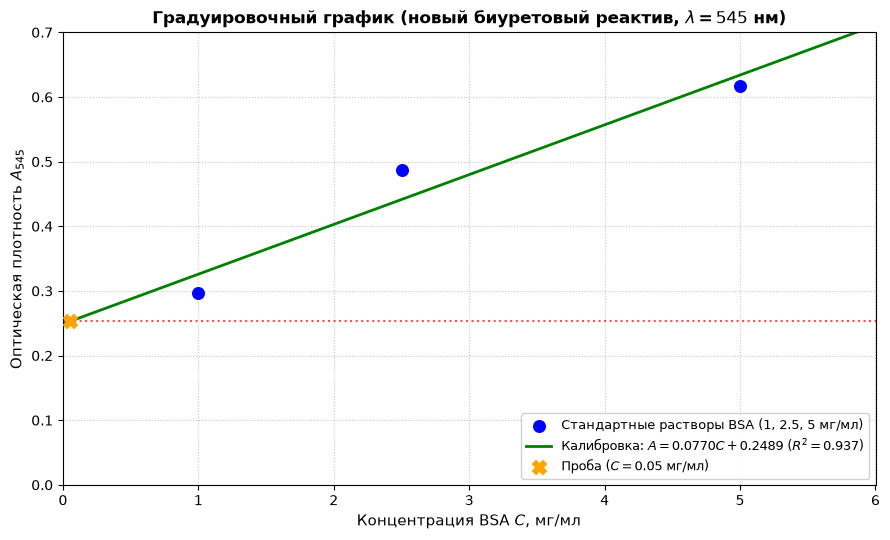

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Данные для градуировочного графика (при lambda = 545 нм)
# AM21 (1.0 мг/мл), AM22 (2.5 мг/мл), AM23 (5.0 мг/мл)
C_std = np.array([1.0, 2.5, 5.0])
A_std = np.array([0.2970, 0.4876, 0.6166])

# Значение оптической плотности неизвестной пробы AM2X при 545 нм
A_unk = 0.2529

# 2. МНК-аппроксимация (линейная регрессия: A = slope * C + intercept)
slope, intercept = np.polyfit(C_std, A_std, 1)

# Коэффициент детерминации R^2
r2 = np.corrcoef(C_std, A_std)[0, 1]**2

# 3. Расчет концентрации пробы AM2X по калибровочной прямой
C_unk = (A_unk - intercept) / slope

print(f"Уравнение регрессии: A = {slope:.4f} * C + {intercept:.4f}")
print(f"R^2 = {r2:.4f}")
print(f"Рассчитанная концентрация пробы: {C_unk:.2f} мг/мл")

# 4. Отрисовка графика
x_grid = np.linspace(0, 6, 100)

plt.figure(figsize=(9, 5.5))

# Стандартные точки
plt.scatter(C_std, A_std, color='blue', s=70, zorder=5, 
            label='Стандартные растворы BSA (1, 2.5, 5 мг/мл)')

# Градуировочная прямая
plt.plot(x_grid, slope * x_grid + intercept, color='green', linestyle='-', linewidth=2,
         label=f'Калибровка: $A = {slope:.4f}C + {intercept:.4f}$ ($R^2 = {r2:.3f}$)')

# Неизвестная проба AM2X
plt.axhline(y=A_unk, color='red', linestyle=':', alpha=0.7)
plt.scatter([C_unk], [A_unk], color='orange', marker='X', s=100, zorder=6,
            label=f'Проба ($C = {C_unk:.2f}$ мг/мл)')

# Оформление графика
plt.title('Градуировочный график (новый биуретовый реактив, $\lambda = 545$ нм)', fontsize=12, fontweight='bold')
plt.xlabel('Концентрация BSA $C$, мг/мл', fontsize=11)
plt.ylabel('Оптическая плотность $A_{545}$', fontsize=11)
plt.xlim(0, 6)
plt.ylim(0, 0.7)
plt.grid(True, linestyle=':', alpha=0.7)

# Легенда в правом нижнем углу
plt.legend(fontsize=9, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.show()